In [1]:
# IMPORTACIONES DE LIBRERIAS    
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2 as pg2

In [2]:
# IMPORTACIONES DE DATOS
h7 = pd.read_csv('C:\\SW\\csv\\h7.csv' , sep=';')
h7

,DIA,MES,AÑO,TERMINAL,MONTO,RESPUESTA,MENSAJE,TRX,TARJETA,BIN
0,3,4,2010,AT18,75,1,2,1,4000030000004573,400003
1,15,11,2011,AT05,105,1,4,1,4010020000004524,401002
2,29,9,2010,AT01,75,1,1,1,4000010000002812,400001
3,11,1,2010,AT11,20,1,1,1,4000010000006227,400001
4,9,5,2010,AT18,70,1,1,1,4000040000005154,400004
...,...,...,...,...,...,...,...,...,...,...
10995,21,7,2011,AT23,105,1,3,1,4700040000003961,470004
10996,22,3,2010,AT16,50,1,4,1,4700030000008466,470003
10997,2,9,2010,AT22,145,1,4,1,4800040000008544,480004
10998,20,11,2010,AT08,110,1,1,1,4700040000003404,470004


In [3]:
h7[["RESPUESTA","MONTO"]][h7["AÑO"]==2012].groupby("RESPUESTA").sum()

,MONTO
RESPUESTA,
0,121490
1,311420


<Axes: ylabel='MONTO'>

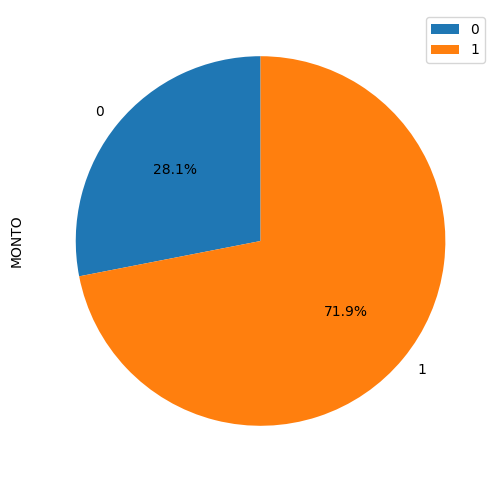

In [4]:
h7[["RESPUESTA","MONTO"]][h7["AÑO"]==2012].groupby("RESPUESTA").sum().plot.pie(y='MONTO', autopct='%1.1f%%', startangle=90, figsize=(6,6))

In [5]:
# Crear conexion de datos

host = '192.168.10.100'
port = '5432'
database = 'DWH'
user = 'test'
password = '123mat'
conn = pg2.connect(host=host, port=port, database=database, user=user, password=password)

# conn = pg2.connect(host='192.168.10.100', port='5432', database='DWH', user='test', password='123mat')

In [6]:
# q = 'SELECT * FROM "Snowflake".fact_transaccionesatm;'
# q = 'SELECT * FROM "Snowflake".dim_terminales;'
q = 'SELECT * FROM "Snowflake".fact_transaccionesatm A left join "Snowflake".dim_terminales B on A.terminal = B.terminal;'

df = pd.read_sql_query(q, conn)
df

C:\Users\celta\AppData\Local\Temp\ipykernel_20788\2604757125.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(q, conn)


,id,dia,mes,agno,terminal,monto,respuesta,mensaje,trx,tarjeta,bin,terminal,tipo,nombre,departamento,ubicacion,direccion
0,3,29,9,2010,AT01,75,1,1,1,4000010000002812,400001,AT01,DEPOSITARIO,OFICINA PRINCIPAL,SV-SS,OFICINA,SAN SALVADOR
1,4,11,1,2010,AT11,20,1,1,1,4000010000006227,400001,AT11,NORMAL,GASOLINERA SAN MIGUEL,SV-SM,GASOLINERA,SAN MIGUEL
2,5,9,5,2010,AT18,70,1,1,1,4000040000005154,400004,AT18,NORMAL,CENTRO COMERCIAL SENSUNTEPEQUE,SV-CA,CENTRO COMERCIAL,SENSUNTEPEQUE
3,6,11,3,2012,AT07,500,1,2,1,4010020000005549,401002,AT07,NORMAL,GASOLINERA SANTA TECLA,SV-LI,GASOLINERA,SANTA TECLA
4,7,18,12,2012,AT12,15,1,1,1,4000010000002502,400001,AT12,NORMAL,SUPERMERCADO SAN SALVADOR,SV-SS,SUPERMERCADO,SAN SALVADOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,10997,22,3,2010,AT16,50,1,4,1,4700030000008466,470003,AT16,NORMAL,SUPERMERCADO USULUTÁN,SV-US,SUPERMERCADO,USULUTÁN
10996,10998,2,9,2010,AT22,145,1,4,1,4800040000008544,480004,AT22,DEPOSITARIO,CENTRO COMERCIAL SAN MIGUEL,SV-SM,CENTRO COMERCIAL,SAN MIGUEL
10997,10999,20,11,2010,AT08,110,1,1,1,4700040000003404,470004,AT08,NORMAL,SUPERMERCADO SAN FRANCISCO GOTERA,SV-MO,SUPERMERCADO,SAN FRANCISCO GOTERA
10998,11000,22,7,2010,AT24,500,1,3,1,4700020000003468,470002,AT24,NORMAL,SUPERMERCADO SAN VICENTE,SV-SV,SUPERMERCADO,SAN VICENTE


In [7]:
df[["ubicacion","monto"]].groupby("ubicacion").sum()

,monto
ubicacion,
CENTRO COMERCIAL,327165
FARMACIA,323660
GASOLINERA,321515
OFICINA,39575
SUPERMERCADO,341625


<Axes: ylabel='monto'>

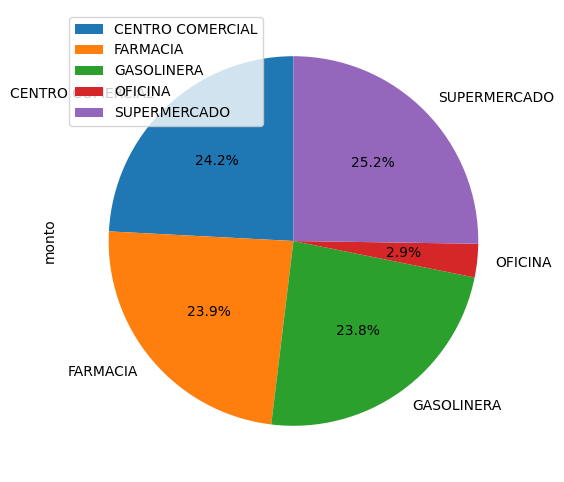

In [8]:
df[["ubicacion","monto"]].groupby("ubicacion").sum().plot.pie(y='monto', autopct='%1.1f%%', startangle=90, figsize=(6,6))